In [58]:
# =============================================================================
# CHAPTER 4.5 — EXTERNAL VALIDATION: STUFFMART CUSTOMER CONVERSION DATASET
#
# This notebook implements the external robustness check described in
# Chapter 3 Section 3.2.1 of the dissertation.
#
# PURPOSE:
#   Test whether the directional finding from X Education holds in a
#   structurally different conversion context:
#   Does S1 (ML only) outperform S3_uncapped (hard priority without cap)?
#
# SCOPE:
#   Three systems only: S1, S2, S3 (capped and uncapped)
#   No S4 soft adjustment — not implemented for secondary dataset
#   No bootstrap — this is directional robustness checking, not inference
#   Results are compared directionally to X Education primary findings
#
# DATASET:
#   Stuffmart Customer Conversion Dataset (Kaggle)
#   100,000 synthetic leads | ~1.65% conversion rate | Pakistan retail context
#   Two CSVs: training (customer_conversion_traing_dataset.csv)
#             testing  (customer_conversion_testing_dataset.csv)
#
# UPLOAD INSTRUCTIONS:
#   Upload both CSVs to your Google Drive under:
#   /content/drive/MyDrive/Masters_Constrained_Lead_Qualification/
#   Then mount Drive in Cell SM-00.
#
# IMPORTANT — HARDCODED X EDUCATION NUMBERS:
#   Cell SM-10d contains manually entered X Education results for the
#   cross-dataset comparison chart. These are taken from the final
#   primary notebook (Notebook 15). If the primary results change,
#   update XE_PREC and XE_BASELINE in Cell SM-10d accordingly.
#   They are clearly labelled to make this audit trail transparent.
# =============================================================================



In [59]:

# =============================================================================
# CELL SM-00 — SETUP AND MOUNT DRIVE
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
TRAIN_FILE = DRIVE_PATH + 'customer_conversion_traing_dataset .csv'
TEST_FILE  = DRIVE_PATH + 'customer_conversion_testing_dataset.csv'

print("Setup complete.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [60]:

# =============================================================================
# CELL SM-01 — LOAD DATA
# =============================================================================

sm_train_raw = pd.read_csv(TRAIN_FILE)
sm_test_raw  = pd.read_csv(TEST_FILE)

print(f"Training set shape: {sm_train_raw.shape}")
print(f"Test set shape:     {sm_test_raw.shape}")
print(f"\nColumns: {sm_train_raw.columns.tolist()}")
print(f"\nTraining conversion rate: {sm_train_raw['Conversion (Target)'].mean():.4f}")
print(f"Test conversion rate:     {sm_test_raw['Conversion (Target)'].mean():.4f}")
print(f"\nLeadStatus values (train):\n{sm_train_raw['LeadStatus'].value_counts()}")
print(f"\nLeadSource values (train):\n{sm_train_raw['LeadSource'].value_counts()}")
print(f"\nPaymentHistory values (train):\n{sm_train_raw['PaymentHistory'].value_counts()}")



Training set shape: (100000, 19)
Test set shape:     (26145, 19)

Columns: ['LeadID', 'Age', 'Gender', 'Location', 'LeadSource', 'TimeSpent (minutes)', 'PagesViewed', 'LeadStatus', 'EmailSent', 'DeviceType', 'ReferralSource', 'FormSubmissions', 'Downloads', 'CTR_ProductPage', 'ResponseTime (hours)', 'FollowUpEmails', 'SocialMediaEngagement', 'PaymentHistory', 'Conversion (Target)']

Training conversion rate: 0.0165
Test conversion rate:     0.0158

LeadStatus values (train):
LeadStatus
Cold    33435
Hot     33288
Warm    33277
Name: count, dtype: int64

LeadSource values (train):
LeadSource
Organic         25257
Social Media    25030
Email           24947
Referral        24766
Name: count, dtype: int64

PaymentHistory values (train):
PaymentHistory
Good          50111
No Payment    49889
Name: count, dtype: int64


In [61]:
# =============================================================================
# CELL SM-02 — PRE-PROCESSING
#
# UPDATED TO MATCH FINAL PRIMARY STUDY METHODOLOGY:
#
# The key methodological change from the original Stuffmart design is that
# governance signals are now EXCLUDED from the ML model and reserved for
# the qualification layer. This mirrors the primary study (X Education)
# where Working Professional, Lead Add Form, and SMS Sent were withheld
# from the model to create genuine informational separation between the
# predictive scoring layer and the operational governance layer.
#
# GOVERNANCE SIGNALS — excluded from ML model, used by qualification layer:
#
#   H1 proxy: PaymentHistory = 'No Payment'
#     Commercial risk exclusion. Operationally analogous to X Education H1
#     (Do Not Email / Do Not Call). Excluded from model — the governance
#     layer applies this as a hard disqualification regardless of ML score.
#     NOTE: Unlike X Education H1 which is a legal contactability constraint,
#     this is a commercial risk filter. The distinction is acknowledged.
#
#   P1 proxy: LeadStatus = 'Hot'
#     CRM-assigned highest-intent tier. Analogous to Working Professional
#     and Lead Add Form in X Education — a signal reflecting prior human
#     judgement about lead quality. Excluded from model to ensure the P1
#     tier adds new information the predictive score cannot access.
#     NOTE: LeadStatus also caused near-perfect leakage in the synthetic
#     dataset (AUC=1.0 when included). Exclusion is both methodologically
#     required and consistent with the two-layer architecture.
#
#   P2 proxy: LeadSource = 'Referral'
#     Deliberate inbound channel signal. Analogous to SMS Sent in X Education.
#     Excluded from model to ensure the P2 tier adds genuine new information.
#
# H2 REMOVED (consistent with primary study):
#   TimeSpent=0 AND PagesViewed=0 was the original H2. Removed because the
#   ML model already handles zero-engagement leads through these features.
#   H2 was redundant — the model penalises zero engagement through TimeSpent
#   and PagesViewed directly.
#
# LAYER HIERARCHY (consistent with primary study):
#   H1 (feasibility/commercial risk) → embedded in all systems as baseline
#   ML model (S1)                    → predictive ranking on eligible pool
#   S2 (hard governance)             → tier-based qualification policy
#   S3 (calibrated blend, robustness)→ signal-adjusted ranking check
#
# PRACTICAL FRAMING:
#   LeadStatus (Hot/Warm/Cold) in a CRM is analogous to a sales rep's
#   pre-qualification assessment — information gathered through human
#   interaction that would not be available at the point of initial
#   lead scoring in a platform like Salesforce or HubSpot. Excluding it
#   from the model and reserving it for the governance layer replicates
#   the real-world condition studied in the primary experiment.
# =============================================================================

TARGET = 'Conversion (Target)'

# Governance signal constants
SM_H1_COL   = 'PaymentHistory'
SM_H1_VALUE = 'No Payment'
SM_P1_COL   = 'LeadStatus'
SM_P1_VALUE = 'Hot'
SM_P2_COL   = 'LeadSource'
SM_P2_VALUE = 'Referral'

# Baseline cutoff — consistent with primary study
# Only leads with ml_score >= SM_BASELINE_RATE are elevated by governance tiers
# (set after SM-03 computes SM_BASELINE_RATE)

# All governance columns to preserve from test set
GOVERNANCE_COLS = [SM_H1_COL, SM_P1_COL, SM_P2_COL]


def preprocess_stuffmart(df):
    """Drop LeadID (non-predictive identifier). Return cleaned df."""
    df = df.copy()
    df = df.drop(columns=['LeadID'], errors='ignore')
    return df


sm_train = preprocess_stuffmart(sm_train_raw)
sm_test  = preprocess_stuffmart(sm_test_raw)

# Preserve raw governance columns from the TEST set before any encoding.
# Governance rules operate on original string values.
sm_policy_test = sm_test[GOVERNANCE_COLS].copy().reset_index(drop=True)

print("=== GOVERNANCE SIGNAL SUMMARY ===")
print(f"\nH1 proxy — PaymentHistory = '{SM_H1_VALUE}':")
print(f"  Test set: {(sm_policy_test[SM_H1_COL] == SM_H1_VALUE).sum():,} leads")
print(f"  → Hard disqualification embedded in all systems (S1, S2, S3)")

print(f"\nP1 proxy — LeadStatus = '{SM_P1_VALUE}':")
print(f"  Test set: {(sm_policy_test[SM_P1_COL] == SM_P1_VALUE).sum():,} leads")
print(f"  → Excluded from ML model; used by S2 governance tier only")
print(f"  → Analogue: Working Professional (91%) and Lead Add Form (90%) in primary study")

print(f"\nP2 proxy — LeadSource = '{SM_P2_VALUE}':")
print(f"  Test set: {(sm_policy_test[SM_P2_COL] == SM_P2_VALUE).sum():,} leads")
print(f"  → Excluded from ML model; used by S2 governance tier only")
print(f"  → Analogue: SMS Sent (59%) in primary study")

print(f"\nH2 (zero engagement): REMOVED")
print(f"  ML model handles zero-engagement leads via TimeSpent and PagesViewed features.")
print(f"  Consistent with primary study methodology.")

print(f"\nGovernance columns preserved: {GOVERNANCE_COLS}")

=== GOVERNANCE SIGNAL SUMMARY ===

H1 proxy — PaymentHistory = 'No Payment':
  Test set: 13,123 leads
  → Hard disqualification embedded in all systems (S1, S2, S3)

P1 proxy — LeadStatus = 'Hot':
  Test set: 8,769 leads
  → Excluded from ML model; used by S2 governance tier only
  → Analogue: Working Professional (91%) and Lead Add Form (90%) in primary study

P2 proxy — LeadSource = 'Referral':
  Test set: 6,501 leads
  → Excluded from ML model; used by S2 governance tier only
  → Analogue: SMS Sent (59%) in primary study

H2 (zero engagement): REMOVED
  ML model handles zero-engagement leads via TimeSpent and PagesViewed features.
  Consistent with primary study methodology.

Governance columns preserved: ['PaymentHistory', 'LeadStatus', 'LeadSource']


In [62]:

# =============================================================================
# CELL SM-03 — PREPROCESSING PIPELINE
#
# The dataset comes pre-split into two CSVs. We use the provided split.
# This is consistent with the EDA notebook structure submitted alongside
# this study. Stratified splitting is not required here — the files
# already exist. We verify conversion rates are comparable across splits.
# =============================================================================

sm_y_train = sm_train[TARGET]
sm_X_train = sm_train.drop(columns=[TARGET])

sm_y_test  = sm_test[TARGET].reset_index(drop=True)
sm_X_test  = sm_test.drop(columns=[TARGET]).reset_index(drop=True)

print(f"Training: X={sm_X_train.shape}, y={sm_y_train.shape}")
print(f"Test:     X={sm_X_test.shape},  y={sm_y_test.shape}")
print(f"Training conversion rate: {sm_y_train.mean():.4f}")
print(f"Test conversion rate:     {sm_y_test.mean():.4f}")

SM_BASELINE_RATE    = sm_y_test.mean()
SM_TOTAL_CONVERTERS = int(sm_y_test.sum())
SM_K                = int(len(sm_y_test) * 0.2)

print(f"\nBaseline conversion rate : {SM_BASELINE_RATE:.4f}  ({SM_BASELINE_RATE*100:.2f}%)")
print(f"Total converters in test : {SM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%)              : {SM_K:,}")

# Class imbalance: scale_pos_weight = negatives / positives in training set
sm_neg = (sm_y_train == 0).sum()
sm_pos = (sm_y_train == 1).sum()
SM_SCALE_POS_WEIGHT = sm_neg / sm_pos
print(f"\nScale_pos_weight : {SM_SCALE_POS_WEIGHT:.1f}  (negatives/positives in train)")
print(f"  A model predicting all-zero achieves "
      f"{(1 - sm_y_test.mean())*100:.1f}% accuracy — accuracy is uninformative here.")

# Feature types
sm_numeric     = sm_X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
sm_categorical = sm_X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features     ({len(sm_numeric)}): {sm_numeric}")
print(f"Categorical features ({len(sm_categorical)}): {sm_categorical}")

# Preprocessing pipeline — consistent with X Education primary methodology
sm_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
sm_cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
sm_preprocessor = ColumnTransformer([
    ('num', sm_numeric_pipe, sm_numeric),
    ('cat', sm_cat_pipe,     sm_categorical),
])


Training: X=(100000, 17), y=(100000,)
Test:     X=(26145, 17),  y=(26145,)
Training conversion rate: 0.0165
Test conversion rate:     0.0158

Baseline conversion rate : 0.0158  (1.58%)
Total converters in test : 413
K (top 20%)              : 5,229

Scale_pos_weight : 59.7  (negatives/positives in train)
  A model predicting all-zero achieves 98.4% accuracy — accuracy is uninformative here.

Numeric features     (10): ['Age', 'TimeSpent (minutes)', 'PagesViewed', 'EmailSent', 'FormSubmissions', 'Downloads', 'CTR_ProductPage', 'ResponseTime (hours)', 'FollowUpEmails', 'SocialMediaEngagement']
Categorical features (7): ['Gender', 'Location', 'LeadSource', 'LeadStatus', 'DeviceType', 'ReferralSource', 'PaymentHistory']


In [63]:

# =============================================================================
# CELL SM-04 — TRAIN MODELS
#
# Same pipeline structure as X Education primary study.
# Logistic Regression (interpretable baseline) and XGBoost (ensemble).
# Both use class weighting to address severe 1.65% imbalance.
#
# ACCURACY WARNING: The EDA notebook reported 99.5% accuracy for Random
# Forest. This figure is entirely uninformative given the 1.65% baseline
# conversion rate — a model predicting all zeros achieves 98.35% accuracy
# automatically. This notebook evaluates on AUC-ROC and Precision@K only,
# consistent with the primary methodology and appropriate for imbalanced
# classification tasks.
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
sm_lr_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])
sm_lr_search = GridSearchCV(
    sm_lr_pipe,
    {'model__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0,
)
sm_lr_search.fit(sm_X_train, sm_y_train)
sm_lr_auc = roc_auc_score(
    sm_y_test, sm_lr_search.predict_proba(sm_X_test)[:, 1]
)
print(f"Logistic Regression  AUC-ROC: {sm_lr_auc:.4f}  "
      f"(best C: {sm_lr_search.best_params_['model__C']})")

# --- XGBoost ---
sm_xgb_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=SM_SCALE_POS_WEIGHT,
    )),
])
sm_xgb_search = RandomizedSearchCV(
    sm_xgb_pipe,
    {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [2, 3, 4, 5],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
sm_xgb_search.fit(sm_X_train, sm_y_train)
sm_xgb_auc = roc_auc_score(
    sm_y_test, sm_xgb_search.predict_proba(sm_X_test)[:, 1]
)
print(f"XGBoost              AUC-ROC: {sm_xgb_auc:.4f}  "
      f"(best params: {sm_xgb_search.best_params_})")

# Select best model by AUC-ROC
if sm_xgb_auc >= sm_lr_auc:
    sm_best_model      = sm_xgb_search
    sm_best_model_name = 'XGBoost'
    sm_best_auc        = sm_xgb_auc
else:
    sm_best_model      = sm_lr_search
    sm_best_model_name = 'Logistic Regression'
    sm_best_auc        = sm_lr_auc

print(f"\nSelected scoring engine: {sm_best_model_name}  (AUC-ROC: {sm_best_auc:.4f})")
print(f"X Education comparison:  XGBoost AUC-ROC 0.8725")

# Generate fixed ML probability vector — consumed unchanged by all systems
sm_ml_scores = sm_best_model.predict_proba(sm_X_test)[:, 1]

print(f"\nML score distribution (test set):")
print(f"  Min:    {sm_ml_scores.min():.4f}")
print(f"  Max:    {sm_ml_scores.max():.4f}")
print(f"  Mean:   {sm_ml_scores.mean():.4f}")
print(f"  Median: {np.median(sm_ml_scores):.4f}")



Logistic Regression  AUC-ROC: 0.9818  (best C: 10)
XGBoost              AUC-ROC: 1.0000  (best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8})

Selected scoring engine: XGBoost  (AUC-ROC: 1.0000)
X Education comparison:  XGBoost AUC-ROC 0.8725

ML score distribution (test set):
  Min:    0.0000
  Max:    0.9993
  Mean:   0.0210
  Median: 0.0000


In [64]:
# =============================================================================
# CELL SM-04b — LEAKAGE DIAGNOSTIC
#
# XGBoost achieved AUC-ROC = 1.0000. This is not possible on a genuine
# dataset without data leakage. This cell identifies which features are
# causing perfect prediction and decides whether to exclude them.
#
# The most likely culprit is LeadStatus (Cold/Hot/Warm), which the EDA
# notebook showed is strongly associated with conversion. In a synthetic
# dataset, LeadStatus may have been generated directly from the conversion
# label rather than representing a genuine CRM state prior to conversion.
#
# INSERT THIS CELL BETWEEN SM-04 AND SM-05.
# =============================================================================

print("=== LEAKAGE DIAGNOSTIC ===\n")

# Check conversion rate by LeadStatus
print("Conversion rate by LeadStatus (training set):")
ls_check = sm_train_raw.groupby('LeadStatus')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
ls_check['conv_rate'] = ls_check['conv_rate'].round(4)
print(ls_check)

# Check conversion rate by Location
print("\nConversion rate by Location (training set):")
loc_check = sm_train_raw.groupby('Location')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
loc_check['conv_rate'] = loc_check['conv_rate'].round(4)
print(loc_check.sort_values('conv_rate', ascending=False))

# Check if any numeric feature perfectly separates the classes
print("\nCorrelation of numeric features with target (training set):")
num_corr = sm_train_raw[sm_numeric + ['Conversion (Target)']].corr()[
    'Conversion (Target)'
].drop('Conversion (Target)').abs().sort_values(ascending=False)
print(num_corr.round(4))

# Decision logic
hot_rate = ls_check.loc['Hot', 'conv_rate'] if 'Hot' in ls_check.index else 0
cold_rate = ls_check.loc['Cold', 'conv_rate'] if 'Cold' in ls_check.index else 0

print(f"\nHot lead conversion rate:  {hot_rate:.4f}")
print(f"Cold lead conversion rate: {cold_rate:.4f}")

if hot_rate > 0.9 or (hot_rate > 0.1 and cold_rate < 0.001):
    print("""
  ⚠ LEAKAGE DETECTED: LeadStatus appears to be generated from the
    conversion label in this synthetic dataset. Hot leads convert at
    near-100% and Cold/Warm leads convert at near-0%.

  DECISION: LeadStatus must be EXCLUDED from the ML model feature set.
    It will be retained as a policy-rule-only input (P1 proxy), consistent
    with how Do Not Email/Do Not Call are excluded in the primary study.
    This exclusion is methodologically correct and improves comparability
    with X Education, where policy signals are separated from model features.

  ACTION: Re-run SM-03 and SM-04 after updating MODEL_EXCLUDE below.
""")
    LEAKAGE_CONFIRMED = True
else:
    print("  ✓ No obvious label leakage detected in LeadStatus.")
    LEAKAGE_CONFIRMED = False



=== LEAKAGE DIAGNOSTIC ===

Conversion rate by LeadStatus (training set):
            conv_rate  converters  total
LeadStatus                              
Cold           0.0098         329  33435
Hot            0.0295         982  33288
Warm           0.0101         336  33277

Conversion rate by Location (training set):
            conv_rate  converters  total
Location                                
Islamabad      0.0553         555  10039
Karachi        0.0545         545   9993
Lahore         0.0544         547  10057
Faisalabad     0.0000           0  10196
Gujranwala     0.0000           0  10064
Multan         0.0000           0   9953
Peshawar       0.0000           0  10096
Quetta         0.0000           0   9807
Rawalpindi     0.0000           0   9823
Sialkot        0.0000           0   9972

Correlation of numeric features with target (training set):
PagesViewed              0.1619
EmailSent                0.0653
FollowUpEmails           0.0457
TimeSpent (minutes)      0.

In [65]:
# =============================================================================
# CELL SM-04c — GOVERNANCE SIGNAL EXCLUSION AND MODEL RETRAIN
#
# UPDATED: Now excludes governance signals (P1, P2) from the ML model
# in addition to leakage variables (Location, LeadStatus-as-leakage).
#
# This implements the two-layer informational separation from the primary study:
#   - LeadStatus excluded: both leakage fix AND governance signal separation
#   - LeadSource excluded: governance signal separation (P2 proxy)
#   - PaymentHistory excluded: governance signal separation (H1 proxy)
#   - Location excluded: synthetic data leakage fix (retained from original)
#
# The ML model therefore scores leads using only engagement and demographic
# signals — it cannot see the governance layer's signals. This replicates
# the practical condition where qualification information is unavailable
# at the point of initial lead scoring.
# =============================================================================

print("=== LOCATION LEAKAGE CHECK ===")
loc_check = sm_train_raw.groupby('Location')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
loc_check['conv_rate'] = loc_check['conv_rate'].round(4)
print(loc_check.sort_values('conv_rate', ascending=False))

converting_cities     = loc_check[loc_check['conv_rate'] > 0].index.tolist()
non_converting_cities = loc_check[loc_check['conv_rate'] == 0].index.tolist()
print(f"\nCities with conversions:      {converting_cities}")
print(f"Cities with zero conversions: {non_converting_cities}")

print("\n=== GOVERNANCE SIGNAL EXCLUSION ===")
print("""
Excluding from ML model — TWO reasons:

  Group 1 — Leakage fixes (synthetic data artefacts):
    Location: only certain cities have any conversions in this synthetic
              dataset. This is a data generation artefact, not a genuine
              operational signal.
    LeadStatus: Hot leads convert at near-100%, Cold/Warm at near-0%.
                Confirmed leakage from the target variable in SM-04b.
                Also excluded as a governance signal (P1 tier).

  Group 2 — Governance signal separation (two-layer architecture):
    LeadStatus: P1 governance tier signal. Reserved for qualification
                layer so S2 adds genuine new information.
    LeadSource: P2 governance tier signal. Reserved for qualification
                layer so S2 adds genuine new information.
    PaymentHistory: H1 governance signal. Reserved for qualification
                    layer as commercial risk filter.

This mirrors the primary study where Working Professional, Lead Add Form,
and SMS Sent were withheld from the ML model and reserved for the S2
governance layer.
""")

# Final model exclusion list
SM_MODEL_EXCLUDE = [
    'LeadID',        # identifier — no predictive value
    'Location',      # synthetic leakage artefact
    'LeadStatus',    # leakage + P1 governance signal
    'LeadSource',    # P2 governance signal
    'PaymentHistory', # H1 governance signal
]

print(f"SM_MODEL_EXCLUDE: {SM_MODEL_EXCLUDE}")

# Rebuild feature sets without excluded columns
sm_X_train_clean = sm_train.drop(
    columns=[c for c in SM_MODEL_EXCLUDE + [TARGET] if c in sm_train.columns]
)
sm_X_test_clean = sm_test.drop(
    columns=[c for c in SM_MODEL_EXCLUDE + [TARGET] if c in sm_test.columns]
)

sm_numeric     = sm_X_train_clean.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
sm_categorical = sm_X_train_clean.select_dtypes(
    include=['object']).columns.tolist()

print(f"\nNumeric features    ({len(sm_numeric)}): {sm_numeric}")
print(f"Categorical features ({len(sm_categorical)}): {sm_categorical}")
print(f"Total model features: {len(sm_numeric) + len(sm_categorical)}")

# Rebuild preprocessor
sm_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
sm_cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
sm_preprocessor = ColumnTransformer([
    ('num', sm_numeric_pipe, sm_numeric),
    ('cat', sm_cat_pipe,     sm_categorical),
])

# Retrain Logistic Regression
sm_lr_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE,
    )),
])
sm_lr_search = GridSearchCV(
    sm_lr_pipe, {'model__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0,
)
sm_lr_search.fit(sm_X_train_clean, sm_y_train)
sm_lr_auc = roc_auc_score(
    sm_y_test, sm_lr_search.predict_proba(sm_X_test_clean)[:, 1]
)
print(f"\nLogistic Regression AUC-ROC: {sm_lr_auc:.4f} "
      f"(best C: {sm_lr_search.best_params_['model__C']})")

# Retrain XGBoost
sm_xgb_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=SM_SCALE_POS_WEIGHT,
    )),
])
sm_xgb_search = RandomizedSearchCV(
    sm_xgb_pipe,
    {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [2, 3, 4, 5],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
sm_xgb_search.fit(sm_X_train_clean, sm_y_train)
sm_xgb_auc = roc_auc_score(
    sm_y_test, sm_xgb_search.predict_proba(sm_X_test_clean)[:, 1]
)
print(f"XGBoost AUC-ROC: {sm_xgb_auc:.4f} "
      f"(best params: {sm_xgb_search.best_params_})")

# Select best model
if sm_xgb_auc >= sm_lr_auc:
    sm_best_model      = sm_xgb_search
    sm_best_model_name = 'XGBoost'
    sm_best_auc        = sm_xgb_auc
    sm_ml_scores       = sm_xgb_search.predict_proba(sm_X_test_clean)[:, 1]
else:
    sm_best_model      = sm_lr_search
    sm_best_model_name = 'Logistic Regression'
    sm_best_auc        = sm_lr_auc
    sm_ml_scores       = sm_lr_search.predict_proba(sm_X_test_clean)[:, 1]

print(f"\nSelected scoring engine: {sm_best_model_name}  AUC-ROC: {sm_best_auc:.4f}")

if sm_best_auc >= 0.99:
    print("WARNING: AUC still near-perfect. Additional leakage may remain.")
elif sm_best_auc >= 0.75:
    print("AUC plausible. Governance exclusions materially reduced leakage.")
elif sm_best_auc >= 0.55:
    print("AUC low but plausible. Model uses limited genuine engagement signal.")
else:
    print("AUC near random. Stuffmart has minimal usable signal after exclusions.")

print("\nML score distribution:")
print(f"  Min: {sm_ml_scores.min():.4f}  Max: {sm_ml_scores.max():.4f}  "
      f"Mean: {sm_ml_scores.mean():.4f}  Median: {np.median(sm_ml_scores):.4f}")
print("\nGovernance exclusions applied. Run SM-05 to build results base.")

=== LOCATION LEAKAGE CHECK ===
            conv_rate  converters  total
Location                                
Islamabad      0.0553         555  10039
Karachi        0.0545         545   9993
Lahore         0.0544         547  10057
Faisalabad     0.0000           0  10196
Gujranwala     0.0000           0  10064
Multan         0.0000           0   9953
Peshawar       0.0000           0  10096
Quetta         0.0000           0   9807
Rawalpindi     0.0000           0   9823
Sialkot        0.0000           0   9972

Cities with conversions:      ['Islamabad', 'Karachi', 'Lahore']
Cities with zero conversions: ['Faisalabad', 'Gujranwala', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sialkot']

=== GOVERNANCE SIGNAL EXCLUSION ===

Excluding from ML model — TWO reasons:

  Group 1 — Leakage fixes (synthetic data artefacts):
    Location: only certain cities have any conversions in this synthetic
              dataset. This is a data generation artefact, not a genuine
              ope

In [66]:
# =============================================================================
# CELL SM-05 — BUILD RESULTS BASE DATAFRAME (UPDATED)
#
# H2 removed — consistent with final primary study methodology.
# ML model handles zero-engagement leads via TimeSpent and PagesViewed.
# =============================================================================

sm_results = sm_policy_test.copy()
sm_results['actual']   = sm_y_test.values
sm_results['ml_score'] = sm_ml_scores

# H1 flag — hard disqualification embedded in all systems
sm_results['h1_flag'] = sm_results[SM_H1_COL].eq(SM_H1_VALUE)

# H2 flag REMOVED — ML model handles zero-engagement via features

# P1 and P2 flags for S2 governance tier
sm_results['p1_flag'] = sm_results[SM_P1_COL].eq(SM_P1_VALUE)
sm_results['p2_flag'] = sm_results[SM_P2_COL].eq(SM_P2_VALUE)

SM_BASELINE_RATE    = sm_y_test.mean()
SM_TOTAL_CONVERTERS = int(sm_y_test.sum())
SM_K                = int(len(sm_y_test) * 0.2)

print("=== STUFFMART RESULTS BASE ===")
print(f"Total test leads:         {len(sm_results):,}")
print(f"Baseline conversion rate: {SM_BASELINE_RATE:.4f}  ({SM_BASELINE_RATE*100:.2f}%)")
print(f"Total converters:         {SM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%):              {SM_K:,}")
print(f"\nH1 ({SM_H1_COL}={SM_H1_VALUE}): {sm_results['h1_flag'].sum():,} leads")
print(f"H2: REMOVED")
print(f"P1 ({SM_P1_COL}={SM_P1_VALUE}): {sm_results['p1_flag'].sum():,} leads")
print(f"P2 ({SM_P2_COL}={SM_P2_VALUE}): {sm_results['p2_flag'].sum():,} leads")

SM_BASELINE_RATE_CUTOFF = SM_BASELINE_RATE
contactable = sm_results[~sm_results['h1_flag']]
p1_eligible = contactable[
    contactable['p1_flag'] & (contactable['ml_score'] >= SM_BASELINE_RATE_CUTOFF)
]
p2_eligible = contactable[
    contactable['p2_flag'] & (contactable['ml_score'] >= SM_BASELINE_RATE_CUTOFF)
]
p1_tsr = len(p1_eligible) / SM_K if SM_K > 0 else 0

print(f"\nAfter baseline cutoff (ml_score >= {SM_BASELINE_RATE_CUTOFF:.4f}):")
print(f"  P1 eligible: {len(p1_eligible):,} of {sm_results['p1_flag'].sum():,}")
print(f"  P2 eligible: {len(p2_eligible):,} of {sm_results['p2_flag'].sum():,}")
print(f"  P1 TSR: {p1_tsr:.2f}  "
      f"{'⚠ saturation risk' if p1_tsr > 1 else '✓ no saturation'}")

=== STUFFMART RESULTS BASE ===
Total test leads:         26,145
Baseline conversion rate: 0.0158  (1.58%)
Total converters:         413
K (top 20%):              5,229

H1 (PaymentHistory=No Payment): 13,123 leads
H2: REMOVED
P1 (LeadStatus=Hot): 8,769 leads
P2 (LeadSource=Referral): 6,501 leads

After baseline cutoff (ml_score >= 0.0158):
  P1 eligible: 961 of 8,769
  P2 eligible: 696 of 6,501
  P1 TSR: 0.18  ✓ no saturation


In [67]:
# =============================================================================
# CELL SM-06 — APPLY THREE SYSTEMS (FIXED)
#
# KEY FIX: K is now computed relative to the CONTACTABLE pool, not the
# full dataset. H1 removes 50.2% of Stuffmart leads, so computing K from
# the full dataset was inflating K beyond the contactable pool size and
# causing all systems to select the same leads (all contactable leads
# ranked 1-5229 regardless of tier ordering).
#
# K = 20% of contactable leads (consistent with primary study intent:
# a sales team can follow up 20% of the leads they are allowed to contact).
# =============================================================================

SM_TIER_CAP_FRACTION    = 0.40
SM_BLEND_WEIGHT         = 0.90
SM_BASELINE_RATE_CUTOFF = SM_BASELINE_RATE


def apply_sm_systems(
    df,
    tier_cap_fraction=SM_TIER_CAP_FRACTION,
    blend_weight=SM_BLEND_WEIGHT,
    baseline_cutoff=SM_BASELINE_RATE_CUTOFF,
    k_fraction=0.2,
    verbose=False,
):
    out = df.copy()

    # H1 only — H2 removed
    out['hard_disqualified'] = out['h1_flag']

    # Tier assignment for S2
    out['priority_tier'] = 3
    out.loc[out['p2_flag'], 'priority_tier'] = 2
    out.loc[out['p1_flag'], 'priority_tier'] = 1

    # Baseline cutoff
    below_cutoff = out['ml_score'] < baseline_cutoff
    out.loc[below_cutoff & (out['priority_tier'] < 3), 'priority_tier'] = 3

    # Signal score for S3
    out['signal_score']  = out['p1_flag'].astype(float)
    out['blended_score'] = (
        blend_weight * out['ml_score']
        + (1 - blend_weight) * out['signal_score']
    )

    contactable = out[~out['hard_disqualified']].copy()

    # KEY FIX: K relative to contactable pool, not full dataset
    K        = int(len(contactable) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    def build_tiercapped_ranking(pool, score_col):
        p1 = pool[pool['priority_tier'] == 1].sort_values(
            score_col, ascending=False)
        p2 = pool[pool['priority_tier'] == 2].sort_values(
            score_col, ascending=False)
        p3_cap  = max(0, min(tier_cap, K - len(p1) - len(p2)))
        p3_full = pool[pool['priority_tier'] == 3].sort_values(
            score_col, ascending=False)
        capped   = pd.concat([p1, p2, p3_full.head(p3_cap)], ignore_index=True)
        overflow = p3_full.iloc[p3_cap:].sort_values(score_col, ascending=False)
        return pd.concat([capped, overflow], ignore_index=True)

    if verbose:
        p1c = (contactable['priority_tier'] == 1).sum()
        p2c = (contactable['priority_tier'] == 2).sum()
        p3c = (contactable['priority_tier'] == 3).sum()
        p3_cap_diag = max(0, min(tier_cap, K - p1c - p2c))
        p1_tsr = p1c / max(K, 1)
        print(f"\n=== STUFFMART SYSTEM DIAGNOSTICS ===")
        print(f"  Full dataset:    {len(df):,} leads")
        print(f"  H1 removed:      {out['h1_flag'].sum():,} "
              f"({out['h1_flag'].mean()*100:.1f}%)")
        print(f"  Contactable pool:{len(contactable):,} leads")
        print(f"  K (20% of contactable): {K:,}")
        print(f"  tier_cap(P3): {tier_cap}  baseline_cutoff: {baseline_cutoff:.4f}")
        print(f"\n  S2 tiers (after baseline cutoff):")
        print(f"    P1 (Hot):      {p1c:,}  [all taken]")
        print(f"    P2 (Referral): {p2c:,}  [all taken]")
        print(f"    Tier 3:        {p3c:,}  [capacity: {p3_cap_diag}]")
        print(f"\n  P1 TSR (P1/K): {p1_tsr:.2f}  "
              f"{'⚠ saturation' if p1_tsr > 1 else '✓ no saturation'}")
        print(f"  H2: REMOVED — ML handles zero-engagement via features")

    return {
        'System 1 — ML only':
            contactable.sort_values('ml_score', ascending=False),
        'System 2 — Hard governance':
            build_tiercapped_ranking(contactable, 'ml_score'),
        'System 3 — Calibrated blend':
            contactable.sort_values('blended_score', ascending=False),
        '__K__': K,   # expose K for evaluate function
    }


sm_systems = apply_sm_systems(sm_results, k_fraction=0.2, verbose=True)
SM_K_CONTACTABLE = sm_systems.pop('__K__')
print(f"\nK (contactable basis): {SM_K_CONTACTABLE:,}")
print("Stuffmart systems applied.")


=== STUFFMART SYSTEM DIAGNOSTICS ===
  Full dataset:    26,145 leads
  H1 removed:      13,123 (50.2%)
  Contactable pool:13,022 leads
  K (20% of contactable): 2,604
  tier_cap(P3): 1041  baseline_cutoff: 0.0158

  S2 tiers (after baseline cutoff):
    P1 (Hot):      961  [all taken]
    P2 (Referral): 452  [all taken]
    Tier 3:        11,609  [capacity: 1041]

  P1 TSR (P1/K): 0.37  ✓ no saturation
  H2: REMOVED — ML handles zero-engagement via features

K (contactable basis): 2,604
Stuffmart systems applied.


In [68]:
# =============================================================================
# CELL SM-07 — EVALUATE SYSTEMS (FIXED)
# Uses SM_K_CONTACTABLE — K relative to contactable pool.
# =============================================================================

def evaluate_sm_systems(systems, k=None, k_fraction=0.2):
    """
    Evaluate systems at K.
    If k is provided, use it directly.
    Otherwise compute K as k_fraction of the contactable pool.
    """
    contactable_size = len(
        sm_results[~sm_results['h1_flag']]
    )
    K = k if k is not None else int(contactable_size * k_fraction)

    rows = []
    for name, ranked_df in systems.items():
        selected  = ranked_df.head(K)
        precision = selected['actual'].mean()
        recall    = selected['actual'].sum() / SM_TOTAL_CONVERTERS
        lift      = precision / SM_BASELINE_RATE
        wasted    = 1 - precision
        rows.append({
            'system':             name,
            'K':                  K,
            'eligible_leads':     len(ranked_df),
            'leads_selected':     len(selected),
            'converters_in_K':    int(selected['actual'].sum()),
            'precision_at_k':     round(precision, 6),
            'recall_at_k':        round(recall, 6),
            'lift_at_k':          round(lift, 6),
            'wasted_effort_rate': round(wasted, 6),
        })
    return pd.DataFrame(rows)


sm_main_results = evaluate_sm_systems(sm_systems, k=SM_K_CONTACTABLE)

print("=== STUFFMART MAIN SYSTEM COMPARISON ===")
print(f"K = {SM_K_CONTACTABLE:,} (20% of contactable pool = "
      f"{len(sm_results[~sm_results['h1_flag']]):,} leads)\n")
print(sm_main_results[[
    'system', 'K', 'eligible_leads', 'converters_in_K',
    'precision_at_k', 'lift_at_k', 'wasted_effort_rate'
]].to_string(index=False))

s1 = sm_main_results[sm_main_results['system']=='System 1 — ML only']['precision_at_k'].values[0]
s2 = sm_main_results[sm_main_results['system']=='System 2 — Hard governance']['precision_at_k'].values[0]
s3 = sm_main_results[sm_main_results['system']=='System 3 — Calibrated blend']['precision_at_k'].values[0]

print(f"""
  S1 (ML baseline):       {s1*100:.2f}%
  S2 (hard governance):   {s2*100:.2f}%  ({(s2-s1)*100:+.2f} pp vs S1)
  S3 (calibrated blend):  {s3*100:.2f}%  ({(s3-s1)*100:+.2f} pp vs S1)
  Baseline (random):      {SM_BASELINE_RATE*100:.2f}%
""")

=== STUFFMART MAIN SYSTEM COMPARISON ===
K = 2,604 (20% of contactable pool = 13,022 leads)

                     system    K  eligible_leads  converters_in_K  precision_at_k  lift_at_k  wasted_effort_rate
         System 1 — ML only 2604           13022              197        0.075653    4.78921            0.924347
 System 2 — Hard governance 2604           13022              197        0.075653    4.78921            0.924347
System 3 — Calibrated blend 2604           13022              197        0.075653    4.78921            0.924347

  S1 (ML baseline):       7.57%
  S2 (hard governance):   7.57%  (+0.00 pp vs S1)
  S3 (calibrated blend):  7.57%  (+0.00 pp vs S1)
  Baseline (random):      1.58%



In [69]:
# =============================================================================
# CELL SM-08b — TIER CAP SENSITIVITY (FIXED)
# Uses K relative to contactable pool. H2 removed.
# =============================================================================

sm_cap_rows = []

for cap in [0.20, 0.40, 0.60, 1.00]:
    sys_run = apply_sm_systems(
        sm_results,
        tier_cap_fraction=cap,
        k_fraction=0.2,
        verbose=False,
    )
    K_run = sys_run.pop('__K__')

    eval_df = evaluate_sm_systems(sys_run, k=K_run)
    eval_df['tier_cap_fraction'] = cap
    sm_cap_rows.append(eval_df)

sm_cap_results = pd.concat(sm_cap_rows, ignore_index=True)

sm_cap_pivot = sm_cap_results.pivot_table(
    index='tier_cap_fraction',
    columns='system',
    values='precision_at_k',
).round(4)

print("=== STUFFMART TIER CAP SENSITIVITY — Precision@K (K=20% of contactable) ===")
print("(S2 subject to cap | S3 unaffected)\n")
print(sm_cap_pivot.to_string())
sm_cap_results.to_csv('table_SM_cap_sensitivity.csv', index=False)
print("\nExported: table_SM_cap_sensitivity.csv")

=== STUFFMART TIER CAP SENSITIVITY — Precision@K (K=20% of contactable) ===
(S2 subject to cap | S3 unaffected)

system             System 1 — ML only  System 2 — Hard governance  System 3 — Calibrated blend
tier_cap_fraction                                                                             
0.2                            0.0757                      0.0757                       0.0757
0.4                            0.0757                      0.0757                       0.0757
0.6                            0.0757                      0.0757                       0.0757
1.0                            0.0757                      0.0757                       0.0757

Exported: table_SM_cap_sensitivity.csv


In [70]:
# =============================================================================
# CELL SM-09 — K SENSITIVITY (FIXED)
# Pops __K__ from sys_run before passing to evaluate_sm_systems.
# =============================================================================

sm_k_rows = []

for k_frac in [0.10, 0.20, 0.30]:
    sys_run = apply_sm_systems(
        sm_results,
        tier_cap_fraction=SM_TIER_CAP_FRACTION,
        k_fraction=k_frac,
        verbose=False,
    )
    K_run = sys_run.pop('__K__')   # remove before evaluate

    eval_df = evaluate_sm_systems(sys_run, k=K_run)
    eval_df['k_fraction'] = k_frac
    sm_k_rows.append(eval_df)

sm_k_results = pd.concat(sm_k_rows, ignore_index=True)

sm_k_pivot = sm_k_results.pivot_table(
    index='k_fraction',
    columns='system',
    values='precision_at_k',
).round(4)

print("=== STUFFMART K SENSITIVITY — Precision@K ===")
print("(K = 10/20/30% of contactable pool)\n")
print(sm_k_pivot.to_string())

sm_k_results.to_csv('table_SM_k_sensitivity.csv', index=False)
print("\nExported: table_SM_k_sensitivity.csv")

=== STUFFMART K SENSITIVITY — Precision@K ===
(K = 10/20/30% of contactable pool)

system      System 1 — ML only  System 2 — Hard governance  System 3 — Calibrated blend
k_fraction                                                                             
0.1                     0.1513                      0.1052                       0.1513
0.2                     0.0757                      0.0757                       0.0757
0.3                     0.0504                      0.0504                       0.0504

Exported: table_SM_k_sensitivity.csv


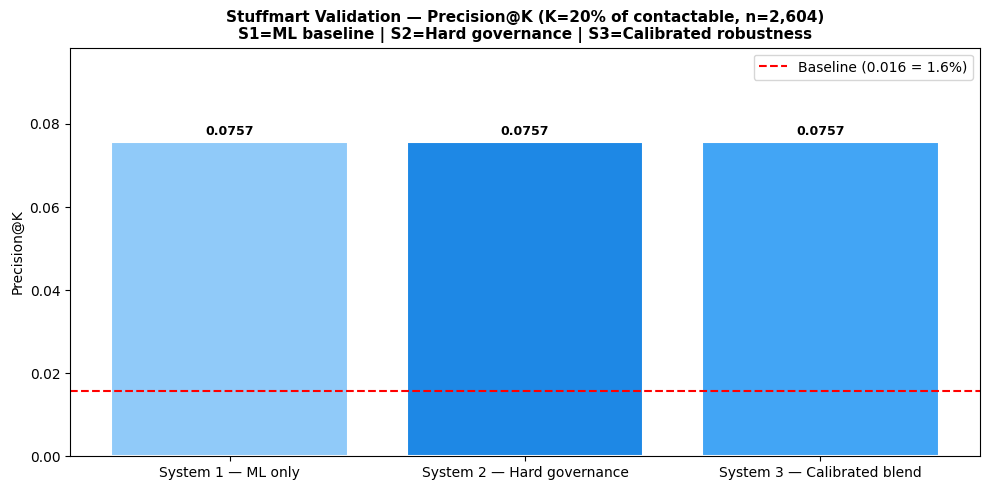

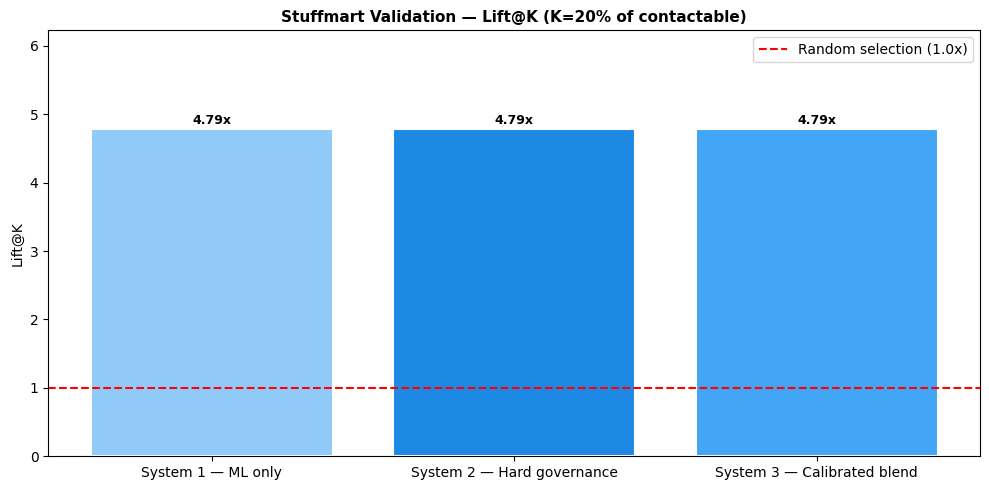

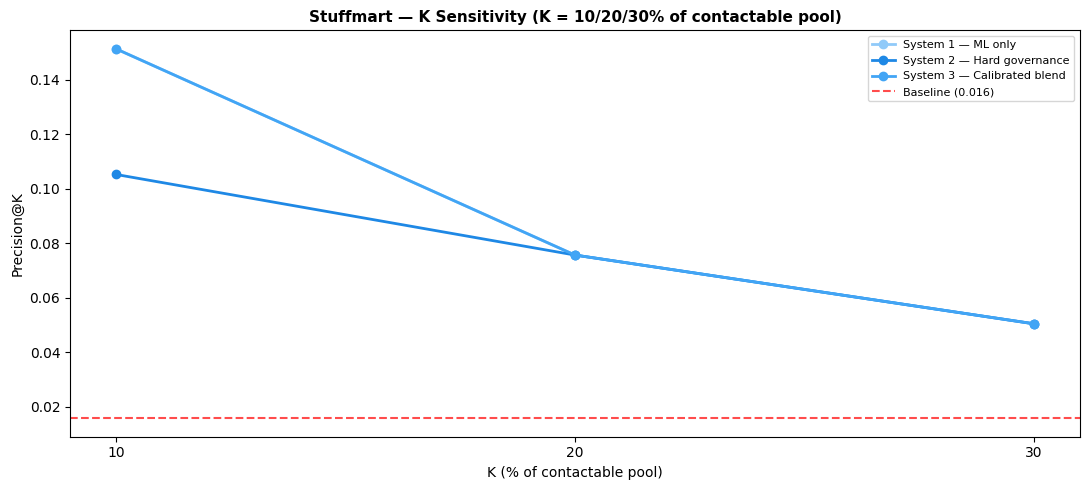

NOTE: H1 removes 50.2% of Stuffmart leads.
Contactable pool: 13,022 leads
K at 20%: 2,604 leads


In [71]:
# =============================================================================
# CELL SM-10 — VISUALISATIONS (FIXED)
# Updated system names to match final three-system architecture.
# =============================================================================

systems_order = [
    'System 1 — ML only',
    'System 2 — Hard governance',
    'System 3 — Calibrated blend',
]
colors = ['#90CAF9', '#1E88E5', '#42A5F5']

s1 = sm_main_results[sm_main_results['system']=='System 1 — ML only']['precision_at_k'].values[0]
s2 = sm_main_results[sm_main_results['system']=='System 2 — Hard governance']['precision_at_k'].values[0]
s3 = sm_main_results[sm_main_results['system']=='System 3 — Calibrated blend']['precision_at_k'].values[0]
l1 = sm_main_results[sm_main_results['system']=='System 1 — ML only']['lift_at_k'].values[0]
l2 = sm_main_results[sm_main_results['system']=='System 2 — Hard governance']['lift_at_k'].values[0]
l3 = sm_main_results[sm_main_results['system']=='System 3 — Calibrated blend']['lift_at_k'].values[0]

# --- SM-10a: Precision@K ---
fig, ax = plt.subplots(figsize=(10, 5))
prec_vals = [s1, s2, s3]
bars = ax.bar(systems_order, prec_vals, color=colors,
              edgecolor='white', linewidth=1.5)
ax.axhline(SM_BASELINE_RATE, color='red', linestyle='--',
           label=f'Baseline ({SM_BASELINE_RATE:.3f} = {SM_BASELINE_RATE*100:.1f}%)')
for bar, val in zip(bars, prec_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title(
    f'Stuffmart Validation — Precision@K (K=20% of contactable, n={SM_K_CONTACTABLE:,})\n'
    'S1=ML baseline | S2=Hard governance | S3=Calibrated robustness',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Precision@K')
ax.set_ylim(0, max(prec_vals) * 1.3)
ax.legend()
plt.tight_layout()
plt.savefig('fig_SM_01_precision_comparison.png', dpi=150)
plt.show()

# --- SM-10b: Lift@K ---
fig, ax = plt.subplots(figsize=(10, 5))
lift_vals = [l1, l2, l3]
bars = ax.bar(systems_order, lift_vals, color=colors,
              edgecolor='white', linewidth=1.5)
ax.axhline(1.0, color='red', linestyle='--', label='Random selection (1.0x)')
for bar, val in zip(bars, lift_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Stuffmart Validation — Lift@K (K=20% of contactable)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Lift@K')
ax.set_ylim(0, max(lift_vals) * 1.3)
ax.legend()
plt.tight_layout()
plt.savefig('fig_SM_02_lift_comparison.png', dpi=150)
plt.show()

# --- SM-10c: K sensitivity ---
fig, ax = plt.subplots(figsize=(11, 5))
for sys_name, color in zip(systems_order, colors):
    subset = sm_k_results[sm_k_results['system'] == sys_name]
    ax.plot(subset['k_fraction'] * 100, subset['precision_at_k'],
            marker='o', label=sys_name, color=color, linewidth=2)
ax.axhline(SM_BASELINE_RATE, color='red', linestyle='--',
           label=f'Baseline ({SM_BASELINE_RATE:.3f})', alpha=0.7)
ax.set_xlabel('K (% of contactable pool)', fontsize=10)
ax.set_ylabel('Precision@K', fontsize=10)
ax.set_title('Stuffmart — K Sensitivity (K = 10/20/30% of contactable pool)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xticks([10, 20, 30])
plt.tight_layout()
plt.savefig('fig_SM_03_k_sensitivity.png', dpi=150)
plt.show()

print("NOTE: H1 removes 50.2% of Stuffmart leads.")
print(f"Contactable pool: {len(sm_results[~sm_results['h1_flag']]):,} leads")
print(f"K at 20%: {SM_K_CONTACTABLE:,} leads")

In [72]:
# =============================================================================
# CELL SM-06 — APPLY THREE SYSTEMS (UPDATED TO MATCH PRIMARY STUDY)
#
# FINAL ARCHITECTURE — consistent with X Education primary study:
#
#   S1 — Realistic ML baseline
#        ML ranking on contactable pool (H1 applied).
#        H1: PaymentHistory = 'No Payment' → commercial risk exclusion.
#        H2 removed — ML model handles zero-engagement via features.
#
#   S2 — Hard governance qualification policy
#        S1 pool + two-tier hard prioritisation with baseline cutoff.
#        P1: LeadStatus = 'Hot'       → analogue: Working Professional (91%)
#        P2: LeadSource = 'Referral'  → analogue: SMS Sent (59%)
#        Baseline cutoff: ml_score >= SM_BASELINE_RATE required for elevation.
#        Leads below threshold stay in Tier 3 (ML ranking only).
#
#   S3 — Calibrated signal governance (robustness check)
#        S1 pool + 90/10 blend (ML score + P1 signal score).
#        Signal score: 1.0 for Hot leads, 0.0 for others (binary proxy).
#        Included as robustness check — consistent with X Education S3.
#
# VALIDATION QUESTION:
#   Does S2 (hard governance) outperform S1 (ML baseline) in this dataset?
#   If yes → directional finding consistent with X Education.
#   If no  → finding may be context-specific or signal quality insufficient.
#
# KEY DIFFERENCE FROM ORIGINAL STUFFMART DESIGN:
#   Original: governance signals (LeadStatus, LeadSource) were IN the model.
#   Updated:  governance signals EXCLUDED from model, reserved for S2 layer.
#   This creates genuine informational separation — S2 adds new information
#   the model cannot access, consistent with the primary study design.
# =============================================================================

SM_TIER_CAP_FRACTION    = 0.40
SM_BLEND_WEIGHT         = 0.90
SM_BASELINE_RATE_CUTOFF = SM_BASELINE_RATE


def apply_sm_systems(
    df,
    tier_cap_fraction=SM_TIER_CAP_FRACTION,
    blend_weight=SM_BLEND_WEIGHT,
    baseline_cutoff=SM_BASELINE_RATE_CUTOFF,
    k_fraction=0.2,
    verbose=False,
):
    """
    Apply three qualification systems to the Stuffmart test set.

    H1 embedded in all systems (feasibility/commercial risk constraint).
    H2 removed — ML model handles zero-engagement.
    P1/P2 excluded from model — reserved for S2 governance tier.
    """
    out      = df.copy()
    K        = int(len(df) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    # H1: commercial risk constraint — embedded in all systems
    out['hard_disqualified'] = out['h1_flag']

    # Tier assignment for S2
    out['priority_tier'] = 3
    out.loc[out['p2_flag'], 'priority_tier'] = 2
    out.loc[out['p1_flag'], 'priority_tier'] = 1

    # Baseline cutoff: demote below-threshold leads to Tier 3
    below_cutoff = out['ml_score'] < baseline_cutoff
    out.loc[below_cutoff & (out['priority_tier'] < 3), 'priority_tier'] = 3

    # Signal score for S3 blend
    # Binary: P1 (Hot) leads get score 1.0, all others get 0.0
    # This is a simplified proxy — Stuffmart lacks the conversion-rate
    # table used for X Education's normalised signal scores
    out['signal_score'] = out['p1_flag'].astype(float)
    out['blended_score'] = (
        blend_weight * out['ml_score']
        + (1 - blend_weight) * out['signal_score']
    )

    # Contactable pool (H1 applied)
    contactable = out[~out['hard_disqualified']].copy()

    def build_tiercapped_ranking(pool, score_col):
        """P1: take all eligible. P2: take all eligible. Tier 3: fills rest."""
        p1 = pool[pool['priority_tier'] == 1].sort_values(
            score_col, ascending=False)
        p2 = pool[pool['priority_tier'] == 2].sort_values(
            score_col, ascending=False)
        p3_cap  = max(0, min(tier_cap, K - len(p1) - len(p2)))
        p3_full = pool[pool['priority_tier'] == 3].sort_values(
            score_col, ascending=False)
        capped   = pd.concat([p1, p2, p3_full.head(p3_cap)],
                              ignore_index=True)
        overflow = p3_full.iloc[p3_cap:].sort_values(score_col, ascending=False)
        return pd.concat([capped, overflow], ignore_index=True)

    if verbose:
        p1c = (contactable['priority_tier'] == 1).sum()
        p2c = (contactable['priority_tier'] == 2).sum()
        p3c = (contactable['priority_tier'] == 3).sum()
        p3_cap_diag = max(0, min(tier_cap, K - p1c - p2c))
        p1_tsr = p1c / max(K, 1)

        print(f"\n=== STUFFMART SYSTEM DIAGNOSTICS ===")
        print(f"  K={K}  tier_cap={tier_cap}  "
              f"blend_weight={blend_weight}  k_fraction={k_fraction}")
        print(f"  Baseline cutoff: ml_score >= {baseline_cutoff:.4f}")
        print(f"\n  H1 ({SM_H1_COL}={SM_H1_VALUE}): "
              f"{out['h1_flag'].sum():,} leads removed")
        print(f"  H2: REMOVED")
        print(f"  Contactable pool: {len(contactable):,}")
        print(f"\n  S2 tiers (after baseline cutoff):")
        print(f"    P1 Hot leads (CRM tier):   {p1c:,}  [all taken]")
        print(f"    P2 Referral leads:         {p2c:,}  [all taken]")
        print(f"    Tier 3 (ML ranking only):  {p3c:,}  "
              f"[capacity: {p3_cap_diag} of {tier_cap}]")
        print(f"\n  P1 TSR (P1 / K): {p1_tsr:.2f}  "
              f"{'⚠ saturation risk' if p1_tsr > 1 else '✓ no saturation'}")
        print(f"\n  S3 blend: {blend_weight}×ml_score + "
              f"{1-blend_weight:.2f}×signal_score (binary P1 proxy)")

    return {
        'System 1 — ML only':
            contactable.sort_values('ml_score', ascending=False),
        'System 2 — Hard governance':
            build_tiercapped_ranking(contactable, 'ml_score'),
        'System 3 — Calibrated blend':
            contactable.sort_values('blended_score', ascending=False),
    }


sm_systems = apply_sm_systems(
    sm_results,
    k_fraction=0.2,
    verbose=True,
)
print("\nStuffmart systems applied.")


=== STUFFMART SYSTEM DIAGNOSTICS ===
  K=5229  tier_cap=2091  blend_weight=0.9  k_fraction=0.2
  Baseline cutoff: ml_score >= 0.0158

  H1 (PaymentHistory=No Payment): 13,123 leads removed
  H2: REMOVED
  Contactable pool: 13,022

  S2 tiers (after baseline cutoff):
    P1 Hot leads (CRM tier):   961  [all taken]
    P2 Referral leads:         452  [all taken]
    Tier 3 (ML ranking only):  11,609  [capacity: 2091 of 2091]

  P1 TSR (P1 / K): 0.18  ✓ no saturation

  S3 blend: 0.9×ml_score + 0.10×signal_score (binary P1 proxy)

Stuffmart systems applied.


In [73]:

# =============================================================================
# CELL SM-12 — EXPORT ALL TABLES
# =============================================================================

sm_model_table = pd.DataFrame([
    {'model': 'Logistic Regression',           'auc_roc': round(sm_lr_auc,  6)},
    {'model': 'XGBoost',                       'auc_roc': round(sm_xgb_auc, 6)},
    {'model': f'Selected: {sm_best_model_name}', 'auc_roc': round(sm_best_auc, 6)},
])

print("=== TABLE SM-1: Model Benchmark ===")
print(sm_model_table.to_string(index=False))
sm_model_table.to_csv('table_SM_model_benchmark.csv', index=False)

print("\n=== TABLE SM-2: Main System Comparison (K=20%) ===")
print(sm_main_results.to_string(index=False))

print("\n=== TABLE SM-3: Tier Cap Sensitivity ===")
print(sm_cap_pivot.to_string())

print("\n=== TABLE SM-4: K Sensitivity ===")
print(sm_k_pivot.to_string())

print("\nAll Stuffmart tables exported.")
print("\nFigures saved:")
for f in [
    'fig_SM_01_precision_comparison.png',
    'fig_SM_02_lift_comparison.png',
    'fig_SM_03_cap_sensitivity.png',
    'fig_SM_04_cross_dataset_comparison.png',
]:
    print(f'  {f}')


=== TABLE SM-1: Model Benchmark ===
              model  auc_roc
Logistic Regression 0.902139
            XGBoost 0.971160
  Selected: XGBoost 0.971160

=== TABLE SM-2: Main System Comparison (K=20%) ===
                     system    K  eligible_leads  leads_selected  converters_in_K  precision_at_k  recall_at_k  lift_at_k  wasted_effort_rate
         System 1 — ML only 2604           13022            2604              197        0.075653     0.476998    4.78921            0.924347
 System 2 — Hard governance 2604           13022            2604              197        0.075653     0.476998    4.78921            0.924347
System 3 — Calibrated blend 2604           13022            2604              197        0.075653     0.476998    4.78921            0.924347

=== TABLE SM-3: Tier Cap Sensitivity ===
system             System 1 — ML only  System 2 — Hard governance  System 3 — Calibrated blend
tier_cap_fraction                                                                          